# Stage 02 Deep Learning Multi-Modal EDA Notebook
## Personalized Precision Medicine for Oncology Treatment Optimization
**Author:** EDA Engineering Team  
**Dataset:** Academic Synthetic Oncology Multi-Modal Dataset (Unstructured Imaging + Longitudinal Biomarkers)  

---

### Objectives:
1. **Multi-Modal Asset Profiling:** Tabular clinical records, Histopathology microscopy, CT scans, MRI sequences, and longitudinal biomarker series.
2. **Computer Vision Characterization:** Class distributions, RGB stain characteristics, spatial projection maps, sharpness (Laplacian variance), and Shannon entropy.
3. **Longitudinal Trajectories:** Temporal dynamics of ctDNA, protein biomarkers, and tumor volume across clinical timepoints.
4. **Data Leakage Verification:** Zero patient ID overlap verification across Train, Validation, and Test splits.
5. **Deep Learning Handoff:** Input preprocessing, tensor shaping, and architectural recommendations.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Libraries and visualization styling configured successfully.")


Libraries and visualization styling configured successfully.



In [ ]:
# Robust path resolution whether run from root or notebooks directory
data_dir = None
for candidate in ['../data', 'data', 'stage2_dl/data', os.path.join(BASE_DIR, 'data')]:
    if os.path.exists(os.path.join(candidate, 'processed', 'dl_cleaned.csv')):
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate stage2_dl data directory.")

df_clean = pd.read_csv(os.path.join(data_dir, 'processed', 'dl_cleaned.csv'))
df_temporal = pd.read_csv(os.path.join(data_dir, 'processed', 'temporal_biomarker_sequences.csv'))
df_split = pd.read_csv(os.path.join(data_dir, 'processed', 'patient_split.csv'))
df_pixel = pd.read_csv(os.path.join(data_dir, 'pixel_images', 'pixel_image_metadata.csv'))

print("=== DATASET INVENTORY LOADED ===")
print(f"Cleaned Encounters:   {df_clean.shape}")
print(f"Temporal Sequences:   {df_temporal.shape}")
print(f"Patient Splits:       {df_split.shape}")
print(f"Pixel Image Metadata: {df_pixel.shape}")


=== DATASET INVENTORY LOADED ===
Cleaned Encounters:   (980, 35)
Temporal Sequences:   (980, 9)
Patient Splits:       (196, 2)
Pixel Image Metadata: (750, 17)



## 1. Clinical Demographics & Encounter Profile
Explore patient demographics, tumor staging, and primary cancer sites.


Summary of Numerical Clinical Features:
          Age  Tumor_Volume_cm3  ctDNA_Level  Protein_Marker_Level  Tumor_Growth_Rate
count  980.00            980.00       980.00                980.00             980.00
mean    55.88             25.93        67.77                137.97              -0.00
std     16.04             16.15        45.17                100.24               0.02
min     28.00              1.90         1.34                  4.75              -0.03
25%     43.00             12.92        33.66                 64.71              -0.02
50%     55.00             23.20        58.31                114.86              -0.00
75%     70.00             35.84        91.97                187.18               0.02
max     82.00             85.64       252.02                523.21               0.04



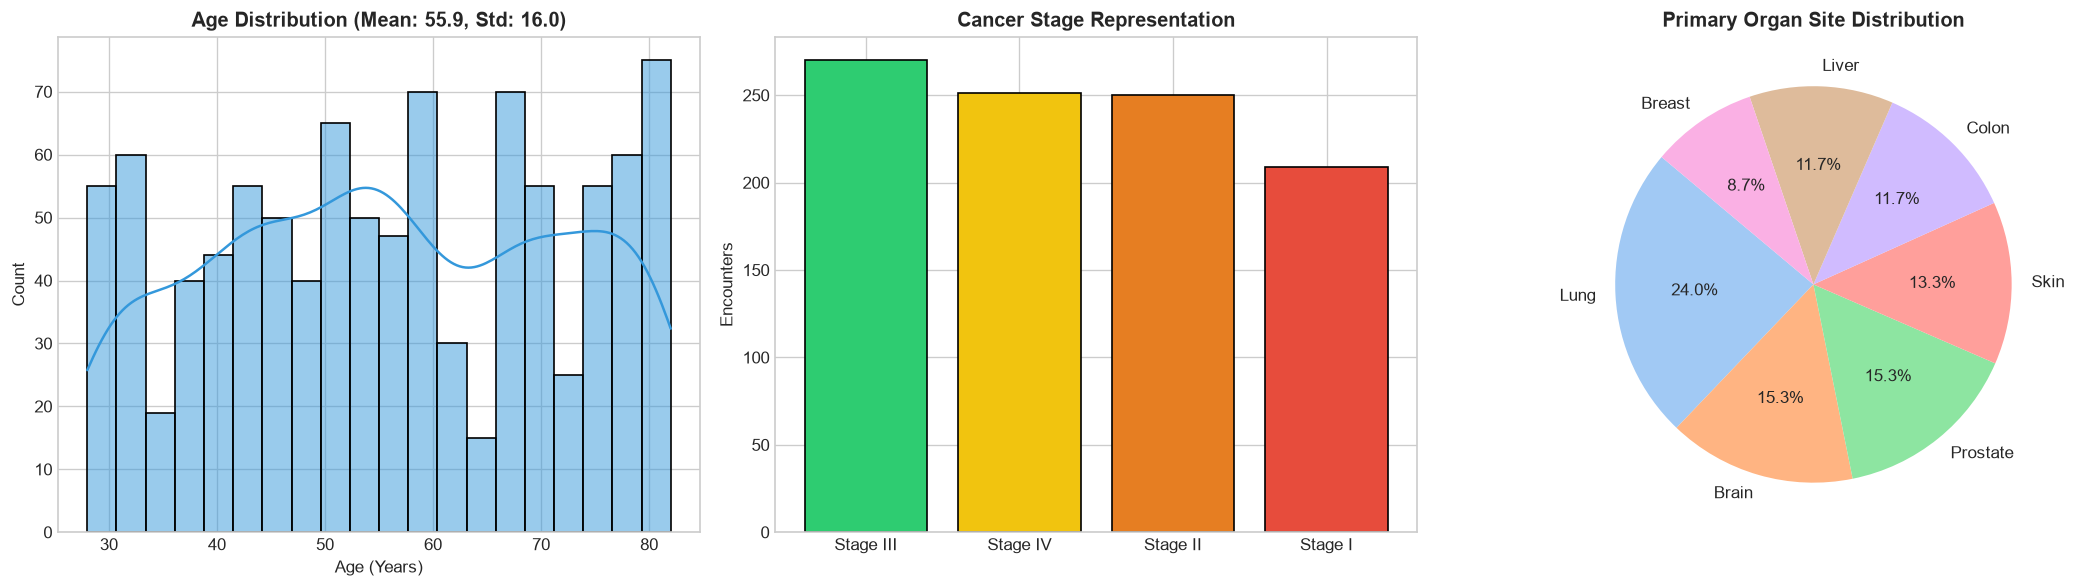

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(df_clean['Age'], bins=20, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title("Age Distribution (Mean: 55.9, Std: 16.0)", fontweight='bold')
axes[0].set_xlabel("Age (Years)")

# Cancer Stage
stage_counts = df_clean['Cancer_Stage'].value_counts()
axes[1].bar(stage_counts.index, stage_counts.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], edgecolor='black')
axes[1].set_title("Cancer Stage Representation", fontweight='bold')
axes[1].set_ylabel("Encounters")

# Primary Organ Site
site_counts = df_clean['Organ_Site'].value_counts()
axes[2].pie(site_counts, labels=site_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
axes[2].set_title("Primary Organ Site Distribution", fontweight='bold')

plt.tight_layout()
plt.show()

print("Summary of Numerical Clinical Features:")
print(df_clean[['Age', 'Tumor_Volume_cm3', 'ctDNA_Level', 'Protein_Marker_Level', 'Tumor_Growth_Rate']].describe().round(2))


## 2. Unstructured Imaging Modality Breakdown & Visual Gallery
Visual and distributional analysis across Histopathology (5 classes), CT (3 classes), and MRI (5 sequences).


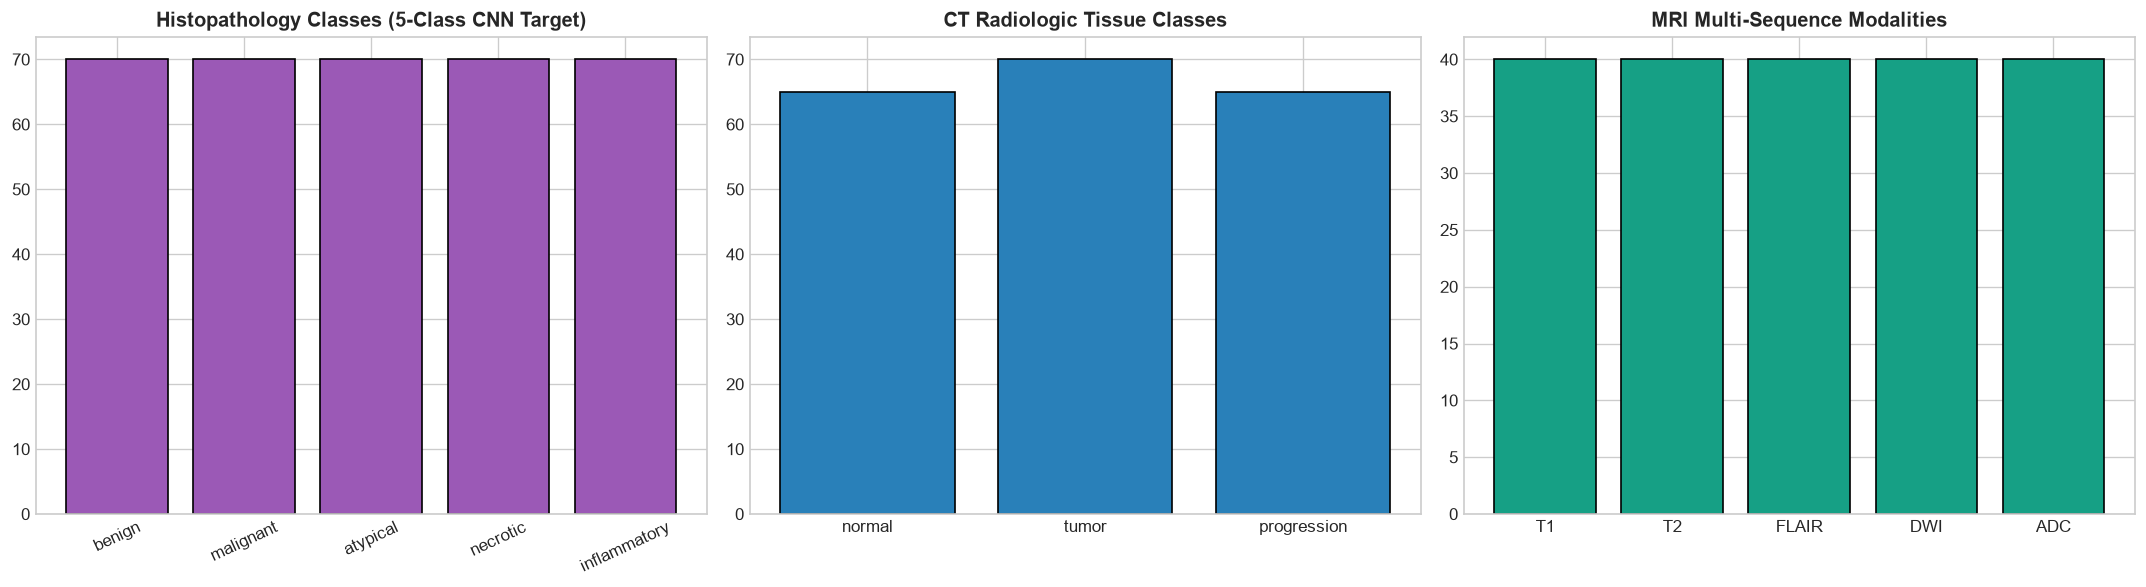

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histopathology Classes
histo_classes = ['benign', 'malignant', 'atypical', 'necrotic', 'inflammatory']
h_counts = [len(glob.glob(os.path.join(data_dir, 'raw', 'histopathology_images', c, '*.png'))) for c in histo_classes]
axes[0].bar(histo_classes, h_counts, color='#9b59b6', edgecolor='black')
axes[0].set_title("Histopathology Classes (5-Class CNN Target)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)

# CT Classes
ct_classes = ['normal', 'tumor', 'progression']
c_counts = [len(glob.glob(os.path.join(data_dir, 'raw', 'ct_images', c, '*.png'))) for c in ct_classes]
axes[1].bar(ct_classes, c_counts, color='#2980b9', edgecolor='black')
axes[1].set_title("CT Radiologic Tissue Classes", fontweight='bold')

# MRI Sequences
mri_seqs = ['T1', 'T2', 'FLAIR', 'DWI', 'ADC']
m_counts = [len(glob.glob(os.path.join(data_dir, 'raw', 'mri_images', s, '*.png'))) for s in mri_seqs]
axes[2].bar(mri_seqs, m_counts, color='#16a085', edgecolor='black')
axes[2].set_title("MRI Multi-Sequence Modalities", fontweight='bold')

plt.tight_layout()
plt.show()


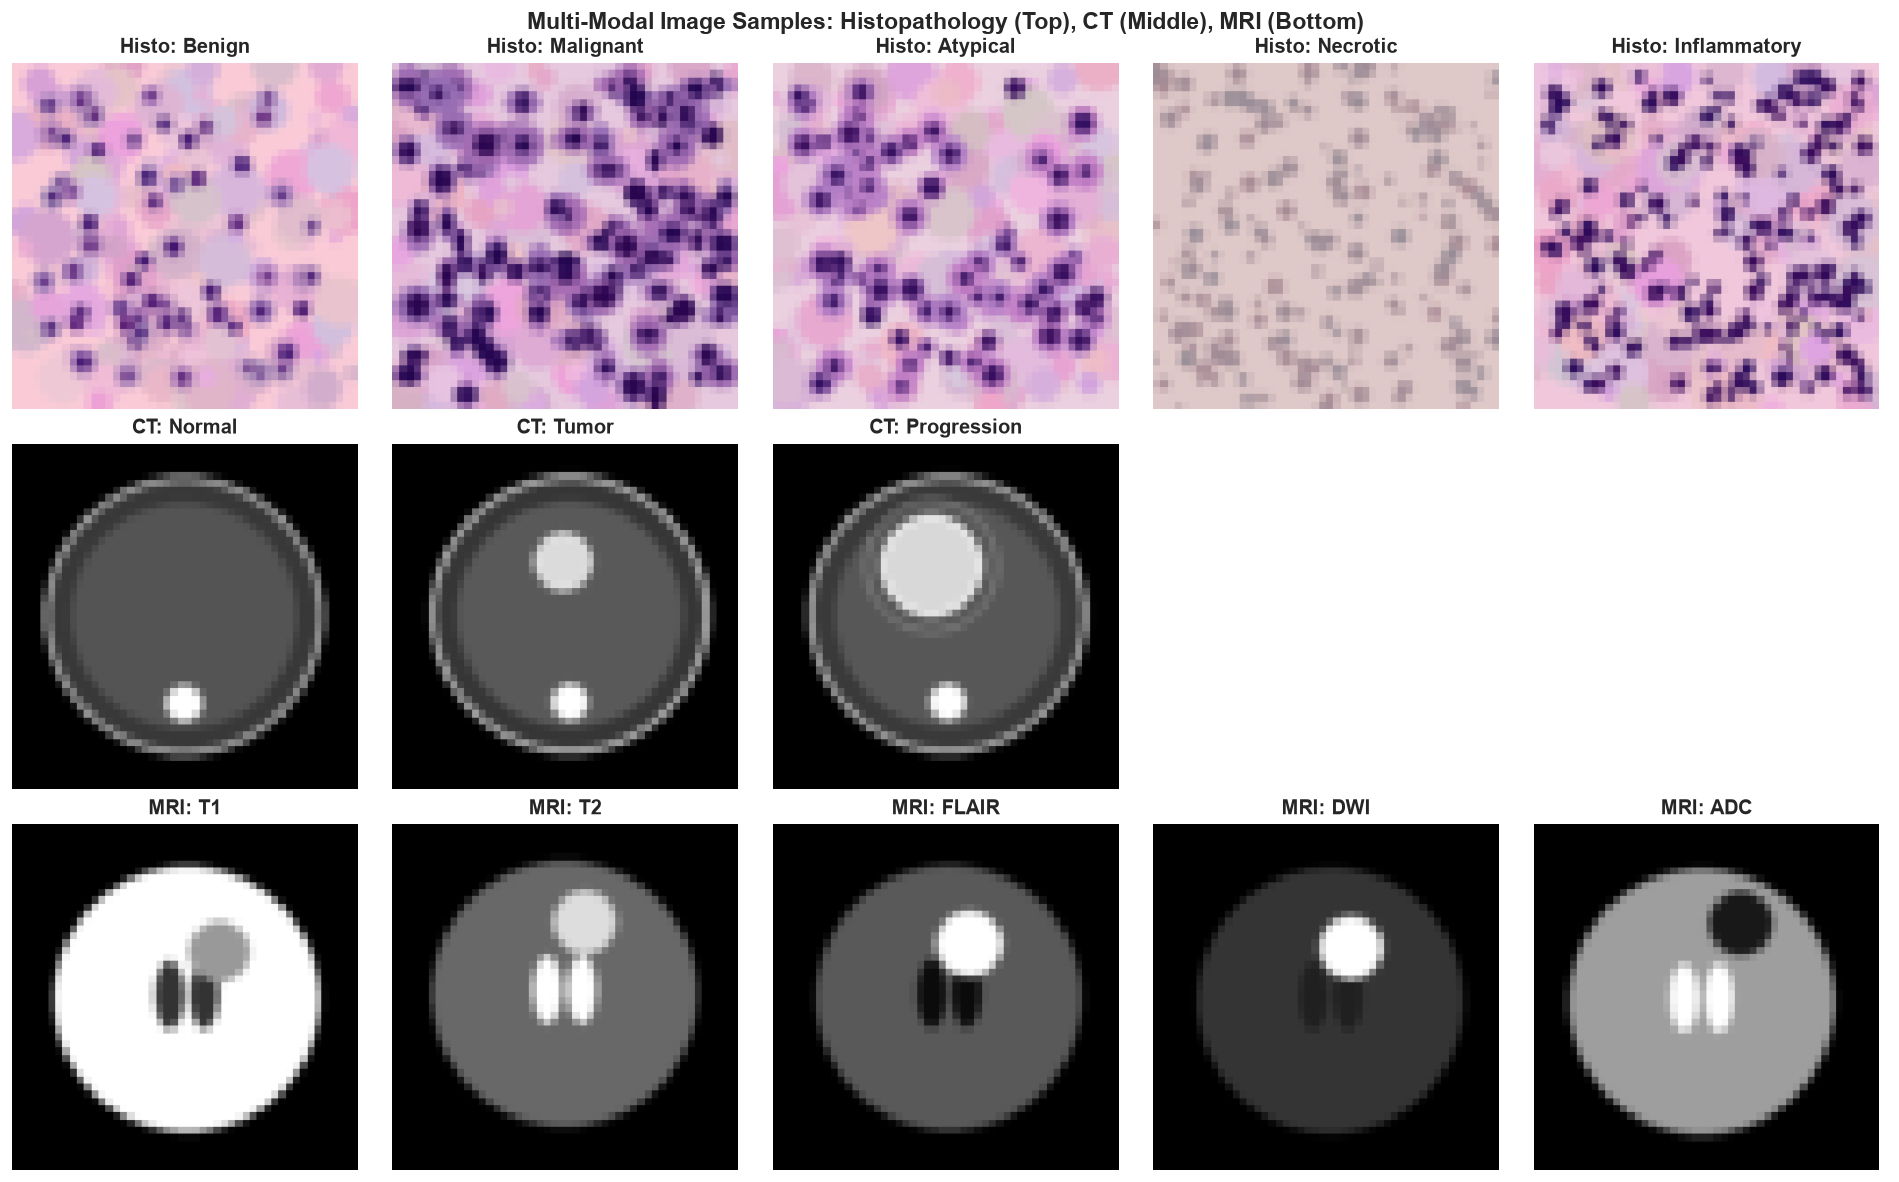

In [ ]:
fig, axs = plt.subplots(3, 5, figsize=(16, 10))

# Row 1: Histopathology
for i, c in enumerate(histo_classes):
    imgs = glob.glob(os.path.join(data_dir, 'raw', 'histopathology_images', c, '*.png'))
    if imgs:
        im = Image.open(imgs[0])
        axs[0, i].imshow(im)
        axs[0, i].set_title(f"Histo: {c.capitalize()}", fontweight='bold')
    axs[0, i].axis('off')

# Row 2: CT
for i, c in enumerate(ct_classes):
    imgs = glob.glob(os.path.join(data_dir, 'raw', 'ct_images', c, '*.png'))
    if imgs:
        axs[1, i].imshow(Image.open(imgs[0]), cmap='gray')
        axs[1, i].set_title(f"CT: {c.capitalize()}", fontweight='bold')
    axs[1, i].axis('off')
axs[1, 3].axis('off')
axs[1, 4].axis('off')

# Row 3: MRI
for i, s in enumerate(mri_seqs):
    imgs = glob.glob(os.path.join(data_dir, 'raw', 'mri_images', s, '*.png'))
    if imgs:
        axs[2, i].imshow(Image.open(imgs[0]), cmap='gray')
        axs[2, i].set_title(f"MRI: {s}", fontweight='bold')
    axs[2, i].axis('off')

plt.suptitle("Multi-Modal Image Samples: Histopathology (Top), CT (Middle), MRI (Bottom)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Histopathology Chromatic & H&E Stain Profiling
RGB channel decomposition representing Hematoxylin (nuclei) and Eosin (cytoplasm) optical densities.


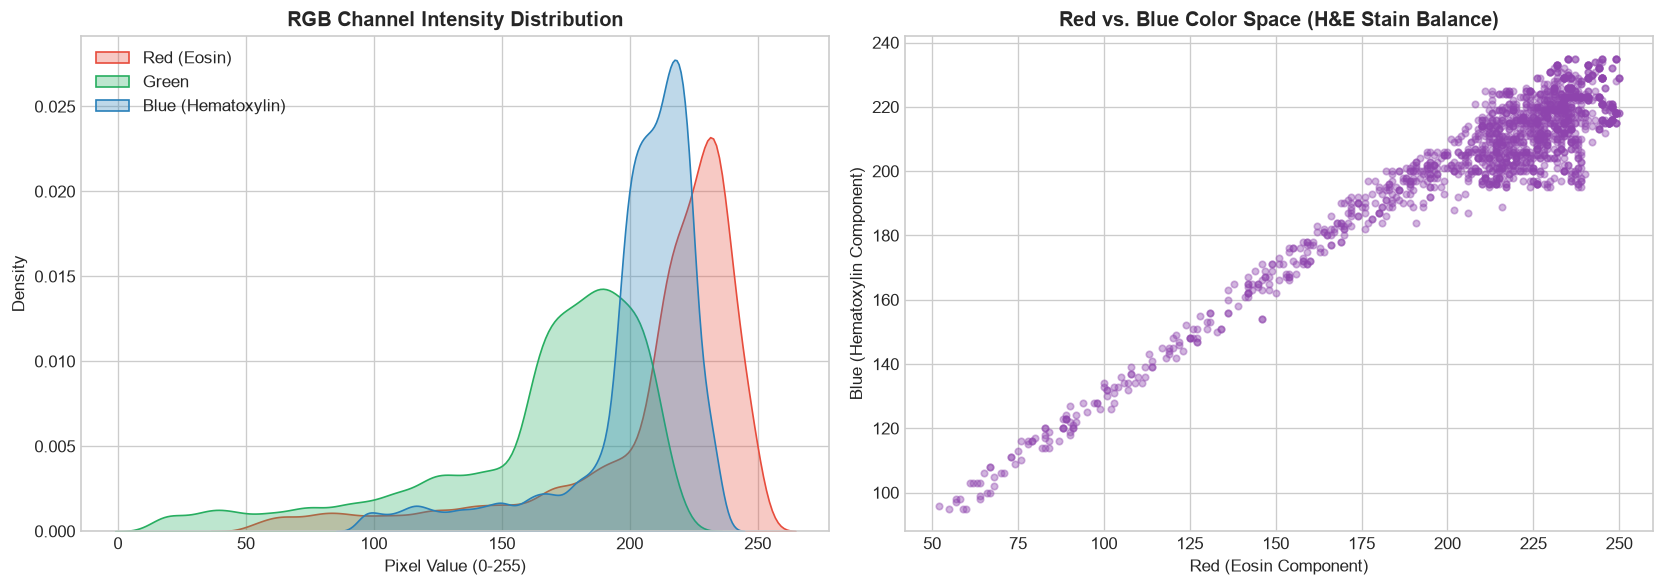

In [ ]:
r_vals, g_vals, b_vals = [], [], []
histo_files = glob.glob(os.path.join(data_dir, 'raw', 'histopathology_images', '**', '*.png'), recursive=True)[:40]

for f in histo_files:
    arr = np.array(Image.open(f).convert('RGB'))
    r_vals.extend(arr[:, :, 0].flatten()[::64])
    g_vals.extend(arr[:, :, 1].flatten()[::64])
    b_vals.extend(arr[:, :, 2].flatten()[::64])

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(r_vals, ax=axs[0], color='#e74c3c', label='Red (Eosin)', fill=True, alpha=0.3)
sns.kdeplot(g_vals, ax=axs[0], color='#27ae60', label='Green', fill=True, alpha=0.3)
sns.kdeplot(b_vals, ax=axs[0], color='#2980b9', label='Blue (Hematoxylin)', fill=True, alpha=0.3)
axs[0].set_title("RGB Channel Intensity Distribution", fontweight='bold')
axs[0].set_xlabel("Pixel Value (0-255)")
axs[0].legend()

# Scatter sample
sub_idx = np.random.choice(len(r_vals), size=min(1500, len(r_vals)), replace=False)
axs[1].scatter(np.array(r_vals)[sub_idx], np.array(b_vals)[sub_idx], color='#8e44ad', alpha=0.4, s=15)
axs[1].set_title("Red vs. Blue Color Space (H&E Stain Balance)", fontweight='bold')
axs[1].set_xlabel("Red (Eosin Component)")
axs[1].set_ylabel("Blue (Hematoxylin Component)")

plt.tight_layout()
plt.show()


## 4. Radiologic Spatial Mean & Standard Deviation Slices
Mean and spatial variation maps identifying structural anatomy and focal tumor masses.


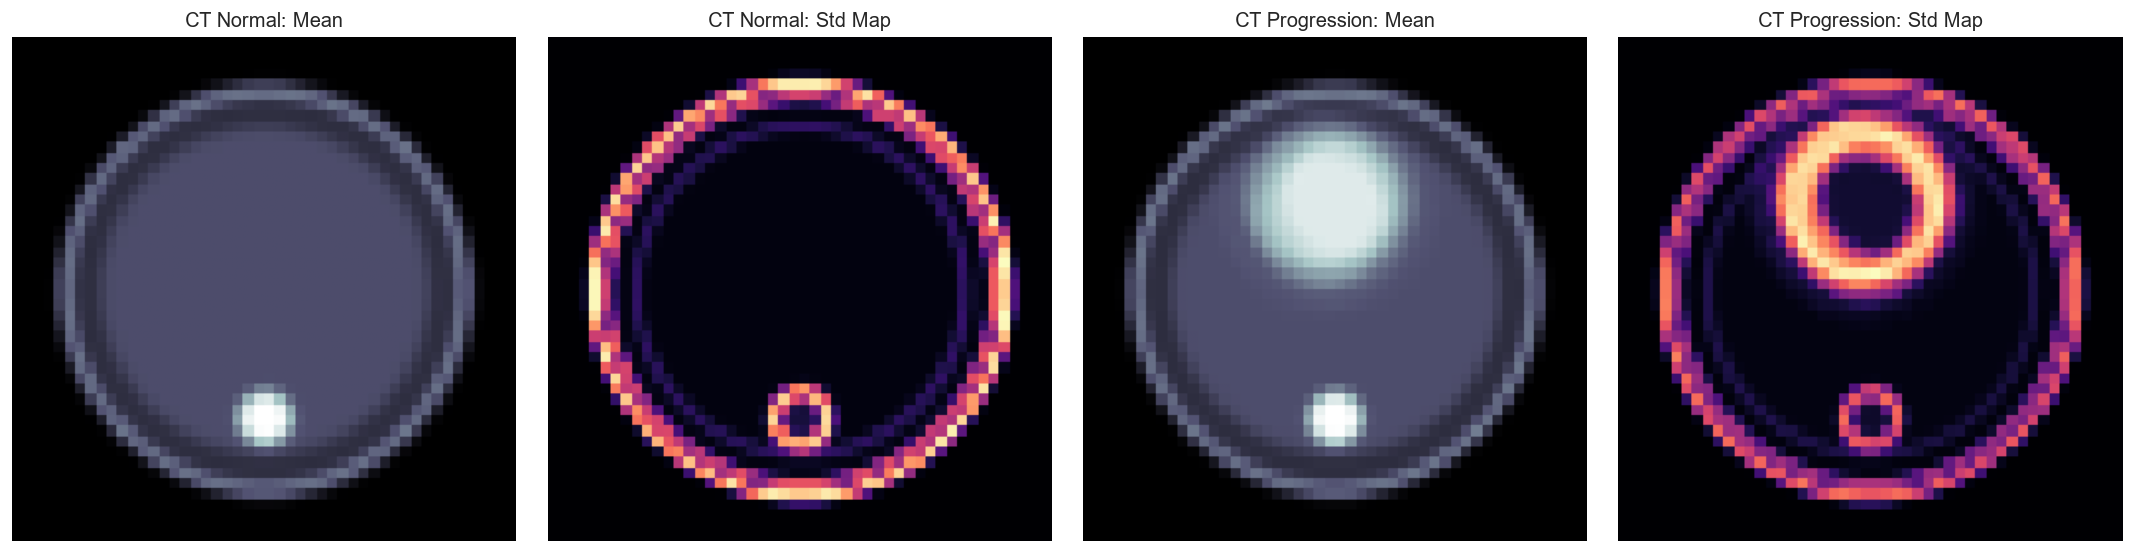

In [ ]:
def compute_spatial_stats(img_paths):
    arrays = [np.array(Image.open(p).convert('L'), dtype=float) for p in img_paths[:30]]
    stack = np.stack(arrays, axis=0)
    return stack.mean(axis=0), stack.std(axis=0)

ct_norm = glob.glob(os.path.join(data_dir, 'raw', 'ct_images', 'normal', '*.png'))
ct_prog = glob.glob(os.path.join(data_dir, 'raw', 'ct_images', 'progression', '*.png'))

mean_norm, std_norm = compute_spatial_stats(ct_norm)
mean_prog, std_prog = compute_spatial_stats(ct_prog)

fig, axs = plt.subplots(1, 4, figsize=(18, 4.5))
axs[0].imshow(mean_norm, cmap='bone'); axs[0].set_title("CT Normal: Mean"); axs[0].axis('off')
axs[1].imshow(std_norm, cmap='magma'); axs[1].set_title("CT Normal: Std Map"); axs[1].axis('off')
axs[2].imshow(mean_prog, cmap='bone'); axs[2].set_title("CT Progression: Mean"); axs[2].axis('off')
axs[3].imshow(std_prog, cmap='magma'); axs[3].set_title("CT Progression: Std Map"); axs[3].axis('off')
plt.tight_layout()
plt.show()


## 5. Longitudinal Biomarker Sequences (LSTM / Transformer Targets)
Trajectories of ctDNA, tumor volume, and protein markers across 5 timepoints (Days 0, 14, 28, 56, 84).


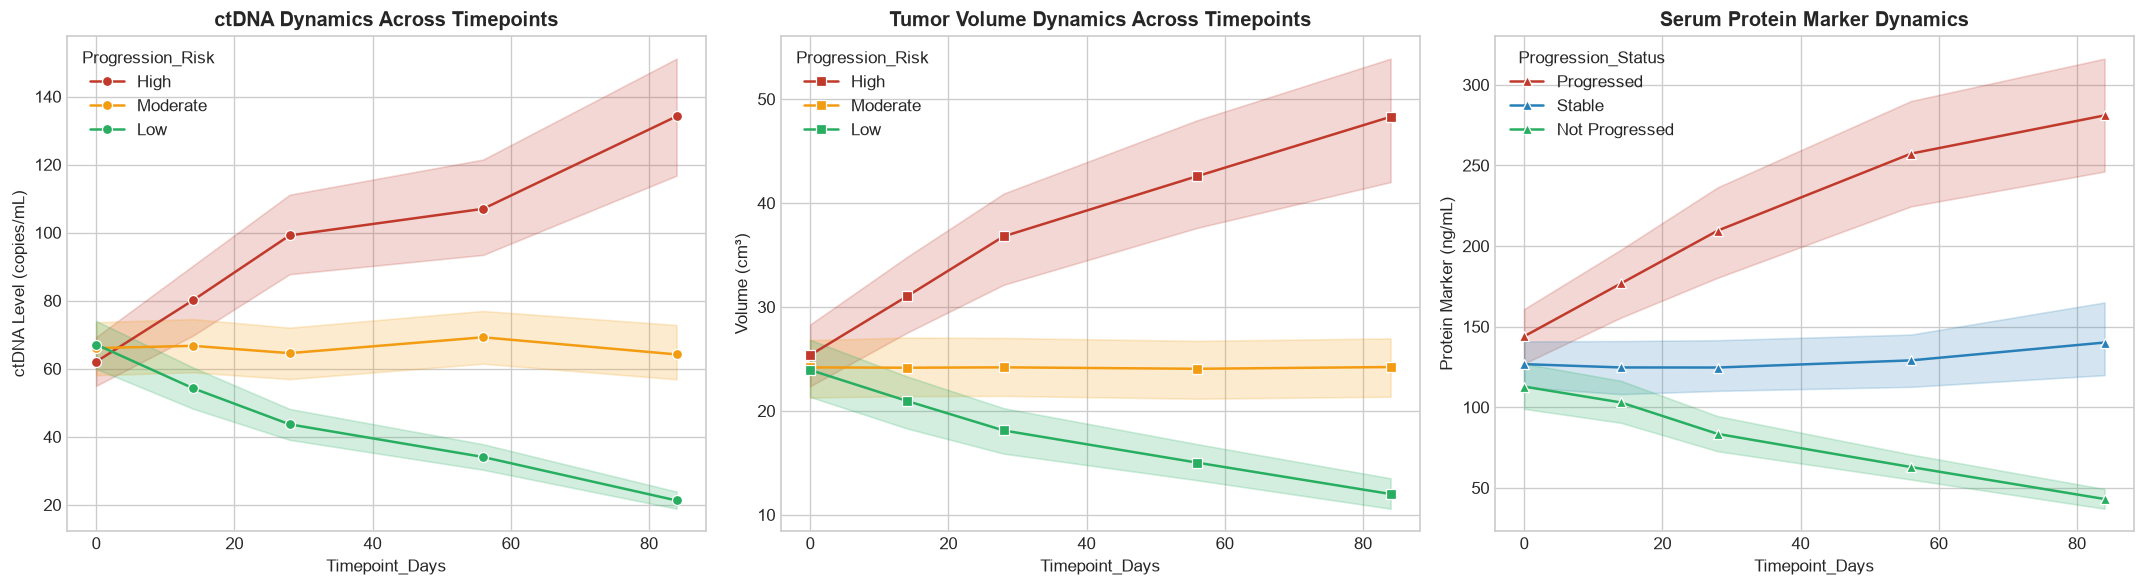

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# ctDNA Trajectory
sns.lineplot(data=df_temporal, x='Timepoint_Days', y='ctDNA_Level', hue='Progression_Risk',
             palette={'Low': '#27ae60', 'Moderate': '#f39c12', 'High': '#c0392b'}, marker='o', ax=axs[0])
axs[0].set_title("ctDNA Dynamics Across Timepoints", fontweight='bold')
axs[0].set_ylabel("ctDNA Level (copies/mL)")

# Tumor Volume Trajectory
sns.lineplot(data=df_temporal, x='Timepoint_Days', y='Tumor_Volume_cm3', hue='Progression_Risk',
             palette={'Low': '#27ae60', 'Moderate': '#f39c12', 'High': '#c0392b'}, marker='s', ax=axs[1])
axs[1].set_title("Tumor Volume Dynamics Across Timepoints", fontweight='bold')
axs[1].set_ylabel("Volume (cm³)")

# Protein Marker Trajectory
sns.lineplot(data=df_temporal, x='Timepoint_Days', y='Protein_Marker_Level', hue='Progression_Status',
             palette={'Not Progressed': '#27ae60', 'Stable': '#2980b9', 'Progressed': '#c0392b'}, marker='^', ax=axs[2])
axs[2].set_title("Serum Protein Marker Dynamics", fontweight='bold')
axs[2].set_ylabel("Protein Marker (ng/mL)")

plt.tight_layout()
plt.show()


## 6. Multi-Modal Correlation Analysis
Correlation heatmap examining relationships between clinical biomarkers and progression risk.


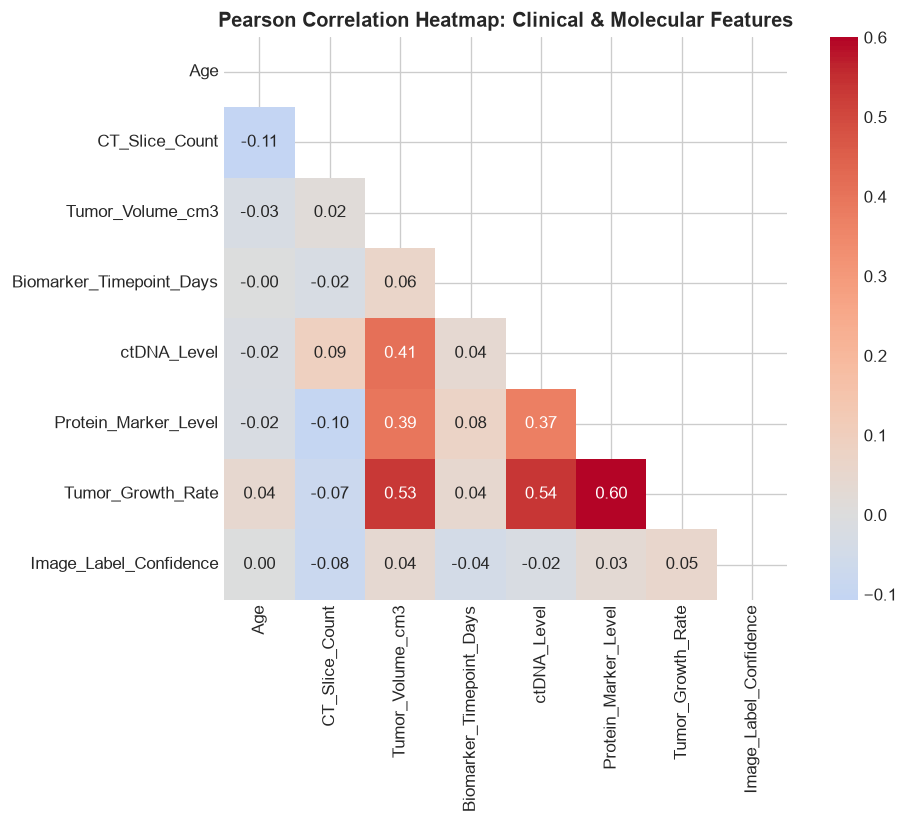

In [ ]:
num_cols = ['Age', 'CT_Slice_Count', 'Tumor_Volume_cm3', 'Biomarker_Timepoint_Days', 
            'ctDNA_Level', 'Protein_Marker_Level', 'Tumor_Growth_Rate', 'Image_Label_Confidence']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title("Pearson Correlation Heatmap: Clinical & Molecular Features", fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Patient-Level Data Leakage Verification
Auditing patient-level grouped splits (GroupShuffleSplit on Patient_ID) to ensure zero data leakage.


In [ ]:
train_pts = set(df_split[df_split['Split'] == 'Train']['Patient_ID'])
val_pts = set(df_split[df_split['Split'] == 'Validation']['Patient_ID'])
test_pts = set(df_split[df_split['Split'] == 'Test']['Patient_ID'])

overlap_tr_val = len(train_pts.intersection(val_pts))
overlap_tr_te = len(train_pts.intersection(test_pts))
overlap_val_te = len(val_pts.intersection(test_pts))

print(f"=== PATIENT-LEVEL LEAKAGE AUDIT ===")
print(f"Total Unique Patients: {len(df_split)}")
print(f"Train Patients:        {len(train_pts)} ({len(train_pts)/len(df_split)*100:.1f}%)")
print(f"Validation Patients:   {len(val_pts)} ({len(val_pts)/len(df_split)*100:.1f}%)")
print(f"Test Patients:         {len(test_pts)} ({len(test_pts)/len(df_split)*100:.1f}%)")
print(f"Train ∩ Validation:    {overlap_tr_val}")
print(f"Train ∩ Test:          {overlap_tr_te}")
print(f"Validation ∩ Test:     {overlap_val_te}")
print(f"STATUS: {'PASS - ZERO LEAKAGE DETECTED' if (overlap_tr_val + overlap_tr_te + overlap_val_te == 0) else 'FAIL - DATA LEAKAGE'}")


=== PATIENT-LEVEL LEAKAGE AUDIT ===
Total Unique Patients: 196
Train Patients:        137 (69.9%)
Validation Patients:   29 (14.8%)
Test Patients:         30 (15.3%)
Train ∩ Validation:    0
Train ∩ Test:          0
Validation ∩ Test:     0
STATUS: PASS - ZERO LEAKAGE DETECTED



## 8. Deep Learning Architecture Recommendations
- **CNN / ViT Team:** Use 350 Histopathology images (`data/processed/image_metadata.csv`). Resize to 224x224, apply ImageNet normalization and rotation/flip augmentations.
- **LSTM / Transformer Team:** Use 980 longitudinal rows (`temporal_biomarker_sequences.csv`). Shape into 3D tensors `(Batch, Timepoints=5, Features=4)`.
- **Loss Strategy:** Employ Focal Loss or Class-Weighted Cross-Entropy to handle the clinical imbalance in high-risk progression.
